# Part II: Polynomial Regression with Multiple Features
## Stellar Luminosity Modeling: L = f(M, T)

**Context:** This notebook extends linear regression to polynomial regression with feature engineering. We model luminosity using both stellar mass (M) and temperature (T), including polynomial and interaction terms.

**Physical motivation:** Temperature provides additional information about stellar structure. The interaction term M×T captures how mass and temperature jointly affect luminosity through nuclear fusion physics.

##Required tasks
1. **Dataset visualization**: plot L vs M and encode T (color or marker size).
2. **Feature engineering**: build X with NumPy vectorization.
3. **Loss and gradients (vectorized)**: implement ME and gradients w.r.t. both w and b.
4. **Gradient descent + convergence**: train and plot loss vs iterations.
5. **Feature selection experiment (mandatory)**: compare:
    * **M1**: X = [M, T]
    * **M2**: X = [M, T, M^2]
    * **M3**: X = [M, T, M^2, M*T]

    For each model: report final loss, learned parameters, and show predicted vs actual (inline plot).
6. **Cost vs interaction (mandatory)**: for the full model (M3), vary the interaction coefficient w_MT across a reasonable range while keeping the other parameters fixed (e.g., at their trained values). Plot cost vs w_MT and explain what it indicates about interaction importance.
7. **Inference demo (mandatory):** predict luminosity for a new star (e.g., M=1.3, T=6600). Comment on reasonableness.

## Setup and Imports

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Configure numpy and matplotlib
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Dataset Definition and Visualization

**Dataset:** 10 main-sequence stars with:
- **M**: Stellar mass (solar masses, M☉)
- **T**: Effective temperature (Kelvin, K)
- **L**: Stellar luminosity (solar luminosities, L☉)

In [71]:
# Dataset: Mass, Temperature, and Luminosity
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])


### 1.1 Visualization: L vs M with Temperature Encoding

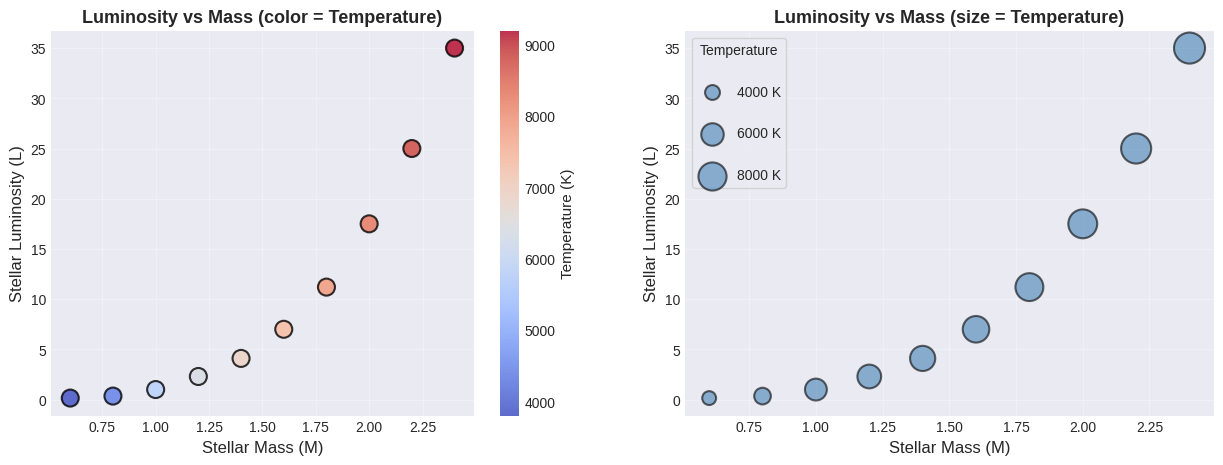

In [72]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: L vs M, color-coded by temperature
scatter1 = axes[0].scatter(M, L, c=T, s=150, cmap='coolwarm',
                           edgecolors='black', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Stellar Mass (M)', fontsize=12)
axes[0].set_ylabel('Stellar Luminosity (L)', fontsize=12)
axes[0].set_title('Luminosity vs Mass (color = Temperature)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Temperature (K)', fontsize=11)

# Right plot: L vs M, size-coded by temperature
# Normalize temperature for marker size (100-500 range)
T_normalized = 100 + 400 * (T - T.min()) / (T.max() - T.min())
scatter2 = axes[1].scatter(M, L, s=T_normalized, c='steelblue',
                           edgecolors='black', linewidth=1.5, alpha=0.6)
axes[1].set_xlabel('Stellar Mass (M)', fontsize=12)
axes[1].set_ylabel('Stellar Luminosity (L)', fontsize=12)
axes[1].set_title('Luminosity vs Mass (size = Temperature)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add legend for size
for temp in [4000, 6000, 8000]:
    size = 100 + 400 * (temp - T.min()) / (T.max() - T.min())
    axes[1].scatter([], [], s=size, c='steelblue', alpha=0.6,
                   edgecolors='black', linewidth=1.5, label=f'{temp} K')
axes[1].legend(scatterpoints=1, frameon=True, labelspacing=2, title='Temperature')
plt.show()

###Observations

* Strong non-linear relationship: luminosity grows rapidly with mass

* Hotter stars (red/yellow points) have both higher mass and higher luminosity

* More massive stars → higher core pressure → higher core temperature

* Higher temperature → faster fusion → more luminosity

## 2. Feature Engineering: Building the Design Matrix X

We construct polynomial features using **vectorized NumPy operations**:

$$X = [M, T, M^2, M \times T]$$

This gives us a design matrix of shape $(m, 4)$ where each row represents one star.


In [11]:
def build_features(M, T, degree='full'):
    """
    Build feature matrix X with polynomial and interaction terms.

    Parameters:
    -----------
    M : array-like, shape (m,)
        Stellar masses
    T : array-like, shape (m,)
        Stellar temperatures
    degree : str
        Feature set to build:
        - 'linear': [M, T]
        - 'quadratic': [M, T, M²]
        - 'full': [M, T, M², M×T]

    Returns:
    --------
    X : array-like, shape (m, n_features)
        Design matrix
    feature_names : list
        Names of features for interpretation
    """
    m = len(M)

    if degree == 'linear':
        # M1: [M, T]
        X = np.column_stack([M, T])
        feature_names = ['M', 'T']

    elif degree == 'quadratic':
        # M2: [M, T, M²]
        X = np.column_stack([M, T, M**2])
        feature_names = ['M', 'T', 'M²']

    elif degree == 'full':
        # M3: [M, T, M², M×T]
        X = np.column_stack([M, T, M**2, M*T])
        feature_names = ['M', 'T', 'M²', 'M×T']

    else:
        raise ValueError(f"Unknown degree: {degree}")

    return X, feature_names


# Build the full feature matrix
X_linear, feature_names_full = build_features(M, T, degree='linear')
X_quadratic, feature_names_full = build_features(M, T, degree='quadratic')
X_full, feature_names_full = build_features(M, T, degree='full')

### 2.1 Feature Scaling


The features have **very different scales**. In practice, feature normalization (standardization) is recommended for faster convergence.

In [44]:
def standardize_features(X):
    """
    Standardization: Scale features to mean=0, std=1.

    Formula: X_scaled = (X - mean) / std

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix where each column is a feature

    Returns:
    --------
    X_scaled : array-like, shape (m, n)
        Standardized feature matrix
    mean : array-like, shape (n,)
        Mean of each feature (for inverse transform or new data)
    std : array-like, shape (n,)
        Standard deviation of each feature
    """
    # Compute mean and std for each feature (column-wise)
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero (if a feature is constant)
    std[std == 0] = 1.0

    # Standardize: (X - mean) / std
    X_scaled = (X - mean) / std

    return X_scaled, mean, std


X_full_scaled, X_full_mean, X_full_std = standardize_features(X_full)

print("Original features:")
print(X_full_scaled[:3])
print("\nScaled features (mean=0, std=1):")
print(X_full_scaled[:3])


print("\nVerification:")
for i, name in enumerate(feature_names_full):
    print(f"{name}: mean={X_full_scaled[:, i].mean():.6f}, std={X_full_scaled[:, i].std():.6f}")

Original features:
[[-1.5667 -1.8012 -1.2702 -1.4162]
 [-1.2185 -1.4515 -1.11   -1.2216]
 [-0.8704 -0.6354 -0.904  -0.8638]]

Scaled features (mean=0, std=1):
[[-1.5667 -1.8012 -1.2702 -1.4162]
 [-1.2185 -1.4515 -1.11   -1.2216]
 [-0.8704 -0.6354 -0.904  -0.8638]]

Verification:
M: mean=-0.000000, std=1.000000
T: mean=0.000000, std=1.000000
M²: mean=0.000000, std=1.000000
M×T: mean=0.000000, std=1.000000


## 3. Loss and Gradients (Vectorized)

### Loss Function (Mean Squared Error)

$$J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})^2$$

In [45]:
def predict(X, w, b):
    """
    Compute predictions using vectorized linear model.

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix
    w : array-like, shape (n,)
        Weight vector
    b : float
        Bias term

    Returns:
    --------
    L_hat : array-like, shape (m,)
        Predictions
    """
    return X @ w + b  # Vectorized: X @ w is matrix-vector product


def compute_cost(X, L, w, b):
    """
    Compute MSE cost function (vectorized).

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix
    L : array-like, shape (m,)
        True luminosities
    w : array-like, shape (n,)
        Weight vector
    b : float
        Bias term

    Returns:
    --------
    cost : float
        MSE cost
    """
    m = X.shape[0]
    L_hat = predict(X, w, b)
    errors = L_hat - L
    cost = (errors @ errors) / (2 * m)
    return cost


def compute_gradients(X, L, w, b):
    """
    Compute gradients using vectorized operations.

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix
    L : array-like, shape (m,)
        True luminosities
    w : array-like, shape (n,)
        Current weights
    b : float
        Current bias

    Returns:
    --------
    dj_dw : array-like, shape (n,)
        Gradient with respect to weights
    dj_db : float
        Gradient with respect to bias
    """
    m = X.shape[0]
    L_hat = predict(X, w, b)
    errors = L_hat - L

    # Vectorized gradient computation
    dj_dw = (1 / m) * (X.T @ errors)  # Shape: (n,)
    dj_db = (1 / m) * np.sum(errors)  # Scalar

    return dj_dw, dj_db


# Test functions with random initialization
n_features = X_full.shape[1]
w_test = np.zeros(n_features)
b_test = 0.0

cost_test = compute_cost(X_full_scaled, L, w_test, b_test)
dw_test, db_test = compute_gradients(X_full_scaled, L, w_test, b_test)

print("Model functions test:")
print(f"Initial cost (w=0, b=0): J = {cost_test:.4f}")
print(f"Initial gradients:")
print(f"  dJ/dw = {dw_test}")
print(f"  dJ/db = {db_test:.4f}")
print("\n✓ Vectorized implementation working correctly!")

Model functions test:
Initial cost (w=0, b=0): J = 117.6967
Initial gradients:
  dJ/dw = [-10.4151  -9.5976 -10.9942 -10.7188]
  dJ/db = -10.3600

✓ Vectorized implementation working correctly!


## 4. Gradient Descent Implementation

Training the model

In [47]:
def gradient_descent(X, L, w_init, b_init, alpha, num_iterations, verbose=True):
    """
    Perform gradient descent optimization.

    Parameters:
    -----------
    X : array-like, shape (m, n)
        Feature matrix
    L : array-like, shape (m,)
        True luminosities
    w_init : array-like, shape (n,)
        Initial weights
    b_init : float
        Initial bias
    alpha : float
        Learning rate
    num_iterations : int
        Number of iterations
    verbose : bool
        Print progress

    Returns:
    --------
    w : array-like, shape (n,)
        Final weights
    b : float
        Final bias
    history : dict
        Training history (cost, w, b)
    """
    w = w_init.copy()
    b = b_init

    history = {
        'cost': [],
        'w': [],
        'b': []
    }

    for i in range(num_iterations):
        # Compute gradients
        dj_dw, dj_db = compute_gradients(X, L, w, b)

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Compute and store cost
        cost = compute_cost(X, L, w, b)
        history['cost'].append(cost)
        history['w'].append(w.copy())
        history['b'].append(b)

        # Print progress
        if verbose and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            w_str = ', '.join([f"{wi:7.4f}" for wi in w])
            print(f"Iter {i:5d}: cost={cost:10.4f}, b={b:8.4f}, w=[{w_str}]")

    return w, b, history




### 4.1 Train Full Model (M3)

Train with all features: $X = [M, T, M^2, M \times T]$

In [60]:
# Initialize parameters
n_features = X_full_scaled.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

# Hyperparameters
alpha = 0.01  # Small learning rate due to large feature scales
num_iterations = 1000

print(f"Training full model (M3) with:")
print(f"  Features: {feature_names_full}")
print(f"  Learning rate: α = {alpha}")
print(f"  Iterations: {num_iterations}")
print("\n" + "="*80)

w_full, b_full, history_full = gradient_descent(
    X_full_scaled, L, w_init, b_init, alpha, num_iterations, verbose=True
)

print("\n" + "="*80)
print("FULL MODEL (M3) RESULTS:")
print("="*80)
for i, name in enumerate(feature_names_full):
    print(f"  w_{name:4s} = {w_full[i]:12.6f}")
print(f"  b      = {b_full:12.6f}")
print(f"\nFinal cost: J = {history_full['cost'][-1]:.6f}")
print("="*80)

Training full model (M3) with:
  Features: ['M', 'T', 'M²', 'M×T']
  Learning rate: α = 0.01
  Iterations: 1000

Iter     0: cost=  112.3510, b=  0.1036, w=[ 0.1042,  0.0960,  0.1099,  0.1072]
Iter   100: cost=   14.9182, b=  6.6058, w=[ 2.5294,  1.8659,  3.1773,  2.8358]
Iter   200: cost=    8.0196, b=  8.9859, w=[ 2.4856,  1.2498,  3.7650,  3.0820]
Iter   300: cost=    6.5116, b=  9.8570, w=[ 2.4003,  0.6301,  4.2777,  3.2720]
Iter   400: cost=    5.7905, b= 10.1759, w=[ 2.3171,  0.0472,  4.7606,  3.4502]
Iter   500: cost=    5.2339, b= 10.2926, w=[ 2.2364, -0.5003,  5.2161,  3.6179]
Iter   600: cost=    4.7519, b= 10.3353, w=[ 2.1583, -1.0144,  5.6458,  3.7759]
Iter   700: cost=    4.3263, b= 10.3510, w=[ 2.0825, -1.4971,  6.0513,  3.9246]
Iter   800: cost=    3.9493, b= 10.3567, w=[ 2.0089, -1.9503,  6.4341,  4.0647]
Iter   900: cost=    3.6153, b= 10.3588, w=[ 1.9375, -2.3757,  6.7954,  4.1966]
Iter   999: cost=    3.3221, b= 10.3596, w=[ 1.8687, -2.7712,  7.1332,  4.3196]

FULL M

### 4.2 Convergence Analysis

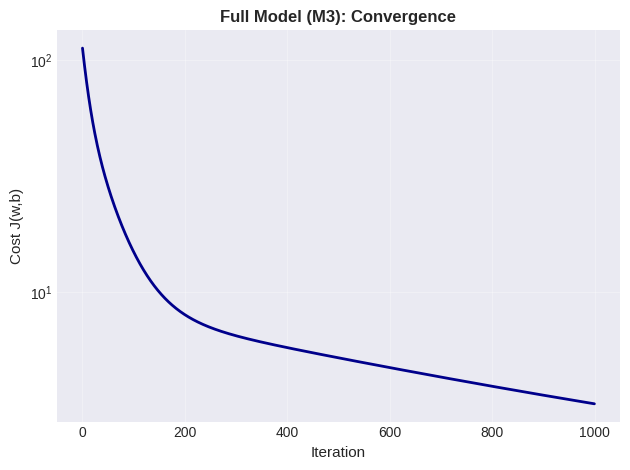


Prediction Quality:
 Star  Actual L  Predicted L  Error
    1      0.15        -2.75  -2.90
    2      0.35        -1.09  -1.44
    3      1.00         0.31  -0.69
    4      2.30         3.07   0.77
    5      4.10         6.37   2.27
    6      7.00        10.14   3.14
    7     11.20        14.37   3.17
    8     17.50        19.09   1.59
    9     25.00        24.24  -0.76
   10     35.00        29.84  -5.16


In [69]:
# Full convergence curve
plt.plot(history_full['cost'], linewidth=2, color='darkblue')
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('Cost J(w,b)', fontsize=11)
plt.title('Full Model (M3): Convergence', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

L_prediction_full = predict(X_full_scaled, w_full, b_full)

# Crear DataFrame
df_results = pd.DataFrame({
    'Star': range(1, len(L) + 1),
    'Actual L': L,
    'Predicted L': L_prediction_full,
    'Error': L_prediction_full - L
})

print(f"\nPrediction Quality:")
print(df_results.to_string(index=False, float_format=lambda x: f'{x:.2f}'))

## 5. Feature Selection Experiment (Mandatory)

Compare three models:
- **M1 (Linear)**: $X = [M, T]$
- **M2 (Quadratic)**: $X = [M, T, M^2]$
- **M3 (Full)**: $X = [M, T, M^2, M \times T]$